## Have you ever wondered what the most popular passwords are?

This dataset intrigued me. Not only does it display the top 500 most common passwords, it also displays how long it takes to crack the passwords, the stregth of the password, and the rank from least to most popular.

I retrieved the data [here](https://github.com/rfordatascience/tidytuesday/blob/main/data/2020/2020-01-14/readme.md), from Github's Tidy Tuesday.

In [1]:
import pandas as pd

pw = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-01-14/passwords.csv')

pw.head(10)

,rank,password,category,value,time_unit,offline_crack_sec,rank_alt,strength,font_size
0,1.0,password,password-related,6.91,years,2.170000e+00,1.0,8.0,11.0
1,2.0,123456,simple-alphanumeric,18.52,minutes,1.110000e-05,2.0,4.0,8.0
2,3.0,12345678,simple-alphanumeric,1.29,days,1.110000e-03,3.0,4.0,8.0
3,4.0,1234,simple-alphanumeric,11.11,seconds,1.110000e-07,4.0,4.0,8.0
4,5.0,qwerty,simple-alphanumeric,3.72,days,3.210000e-03,5.0,8.0,11.0
5,6.0,12345,simple-alphanumeric,1.85,minutes,1.110000e-06,6.0,4.0,8.0
6,7.0,dragon,animal,3.72,days,3.210000e-03,7.0,8.0,11.0
7,8.0,baseball,sport,6.91,years,2.170000e+00,8.0,4.0,8.0
8,9.0,football,sport,6.91,years,2.170000e+00,9.0,7.0,11.0
9,10.0,letmein,password-related,3.19,months,8.350000e-02,10.0,8.0,11.0


The password "password" takes 2.17 seconds to crack. The password "123456" takes 0.0000111 seconds to crack.

## What makes a password easy to crack?

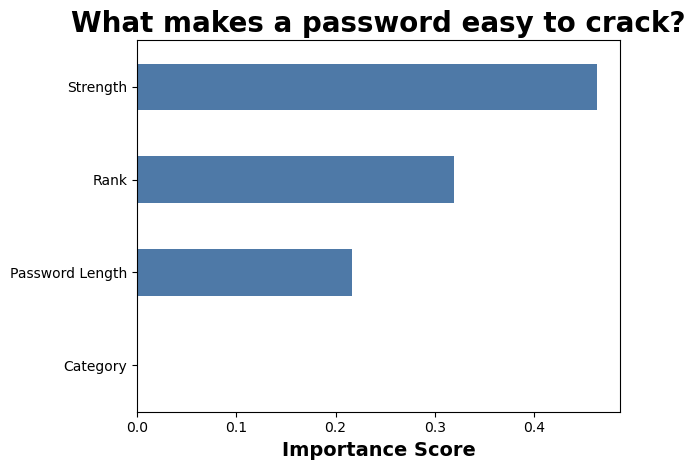

In [12]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

pw_clean = pw.dropna(subset=['strength', 'rank', 'offline_crack_sec'])
pw_clean['category_enc'] = LabelEncoder().fit_transform(pw_clean['category'])

X = pw_clean[['strength', 'rank', 'category_enc']]
X['pw_length'] = pw_clean['password'].str.len()
y = pw_clean['offline_crack_sec']

model = RandomForestRegressor(random_state=42).fit(X, y)
model = RandomForestRegressor(random_state=42).fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.index = ['Category', 'Password Length', 'Rank', 'Strength']
importances.plot(kind='barh', color='#4e79a7')

plt.title('What makes a password easy to crack?', fontsize=20, fontweight='bold')
plt.xlabel('Importance Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

This model was used to predict a password's offline crack time using four features: strength score, password length, rank, and category. The **strength** (quality of password) of the password has the highest importance score, and the category of the password has no importance in predicting the crack time.

## Password Crack Time Accuracy

Here, we will see how accurate a model is at predicting whether a password crack time is slow, medium, or fast.

C:\Users\sunmi\AppData\Local\Temp\ipykernel_26824\3048668353.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pw_clean['crack_category'] = pd.cut(pw_clean['offline_crack_sec'],


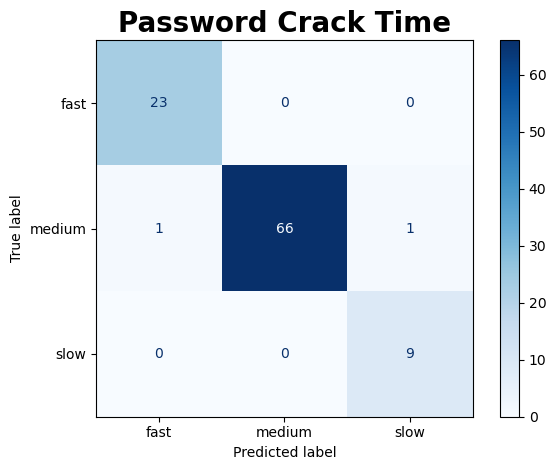

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

pw_clean['crack_category'] = pd.cut(pw_clean['offline_crack_sec'],
                                     bins=[0, 0.001, 1, np.inf],
                                     labels=['fast', 'medium', 'slow'])

pw_clean = pw_clean.dropna(subset=['crack_category'])

pw_clean['category_enc'] = LabelEncoder().fit_transform(pw_clean['category'])
pw_clean['pw_length'] = pw_clean['password'].str.len()

X = pw_clean[['strength', 'rank', 'rank_alt', 'category_enc', 'pw_length']]
y = pw_clean['crack_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=['fast', 'medium', 'slow'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['fast', 'medium', 'slow'])
disp.plot(cmap='Blues')
plt.title('Password Crack Time', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

This model is trained to predict how quickly a password can be cracked based on speed: fast is under 0.001 seconds (wow!), medium is between 0.001-1 seconds, and slow is over 1 second. This is based on features like strength score, rank, password length, and category. It correctly predicted all 23 fast passwords, all 9 slow passwords, and only got 2 medium passwords wrong.

## Top Passwords for Strength

Here is a word cloud of passwords from the dataast, weighted by its strength.

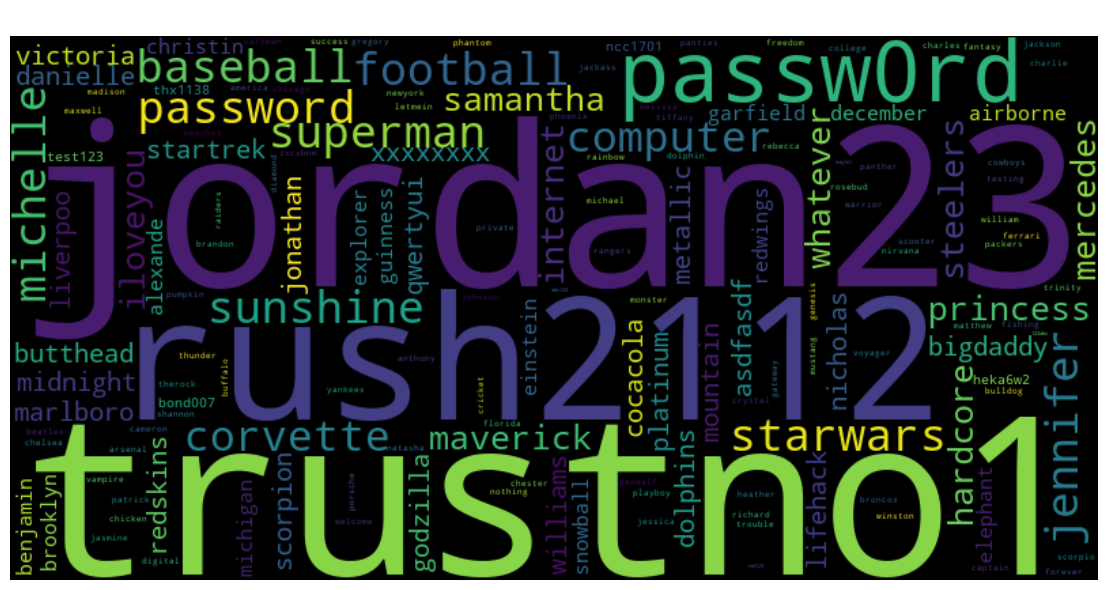

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

weights = dict(zip(pw_clean['password'], pw_clean['offline_crack_sec']))

wc = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(weights)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Passwords sized by strength score', color='white', fontsize=16)
plt.tight_layout()
plt.show()

These are simply the strongest passwords in this dataset of 500 passwords only. So, probably better to not choose these passwords :)!

However, it seems like the best passwords have a mix of both numbers and letters.

## Reflection

Visualization helps make these models more interpretable and trustworthy. The feature importance plot revealed which variables the Random Forest relied on most when predicting how quickly a password could be cracked. The chart showed us that strength score and password length the highest predictors, which also aligns with our understanding of password security. The confusion matrix showed exactly where the model succeeded and where it struggled. The word cloud provided an overview of the strongest passwords in the dataset, which help us understand which passwords to best choose. The strongest passwords in the word cloud have a mix of both numbers and letters, which showed us that it's probably safest for us to include mixed up letters, numbers, and even symbols for our passwords.